# Full Fashion Product Images dataset — exploratory analysis

This notebook explores the newly downloaded **full** Fashion Product Images dataset in `data/train/`. It is intentionally separate from `00_eda.ipynb`, which documents the assignment's official training subset.

## Safety boundary

- The full CSV contains labels for images that belong to the assignment's official held-out test set. Therefore, this notebook is for dataset research only and **must not** be used to train or evaluate the assignment submission until the official test IDs are restored and excluded.
- No train/validation/test split is created here.
- The image directory is about 14 GB and contains high-resolution files. File coverage is checked exhaustively, while pixel dimensions and readability are audited on a deterministic sample to keep the notebook practical.

## Questions

1. Does every metadata row have an image, URL record, and JSON record?
2. Which fields are missing, imbalanced, or unusually rare?
3. How do image dimensions, colour modes, and file sizes vary?
4. What changes would be required before this dataset could be used safely for modelling?

In [1]:
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from fashion.config import RANDOM_SEED, ROOT, TARGET_COLUMNS
from fashion.eda import (
    audit_csv,
    audit_image_sample,
    inventory_images,
    plot_image_grid,
    reconcile_ids,
    sample_ids,
    target_distribution,
    target_summary,
)

FULL_CSV = ROOT / "data/train/styles.csv"
IMAGE_LINKS_CSV = ROOT / "data/train/images.csv"
FULL_IMAGE_DIR = ROOT / "data/train/images"
FULL_STYLE_JSON_DIR = ROOT / "data/train/styles"
IMAGE_SAMPLE_SIZE = 512

pd.set_option("display.max_rows", 160)
pd.set_option("display.max_colwidth", 100)

VERSIONS = {
    package: version(package)
    for package in ("pandas", "numpy", "matplotlib", "pillow", "jupyter")
}

assert FULL_CSV.is_file(), f"Missing metadata: {FULL_CSV}"
assert FULL_IMAGE_DIR.is_dir(), f"Missing images: {FULL_IMAGE_DIR}"
VERSIONS

{'pandas': '3.0.5',
 'numpy': '2.5.2',
 'matplotlib': '3.11.1',
 'pillow': '12.3.0',
 'jupyter': '1.1.1'}

## 1. Metadata schema and label semantics

The CSV is read with `keep_default_na=False` through `audit_csv`. This preserves the literal usage label `"NA"` separately from genuinely blank values. The file has ten named header columns, but 22 product names contain unquoted commas. The parser captures their extra fields as audited `Overflow:` columns and reconstructs `productDisplayName` in memory without dropping rows.

In [2]:
styles, schema_audit = audit_csv(FULL_CSV)

schema_summary = pd.Series(
    {
        "metadata_rows": schema_audit.row_count,
        "named_columns": len(styles.columns),
        "physical_columns": schema_audit.physical_columns,
        "phantom_columns": schema_audit.phantom_columns,
        "duplicate_ids": len(schema_audit.duplicate_ids),
        "literal_NA_usage_rows": schema_audit.literal_na_usage_count,
    },
    name="value",
).to_frame()

blank_summary = (
    pd.Series(schema_audit.blank_counts, name="blank_rows")
    .rename_axis("column")
    .to_frame()
    .query("blank_rows > 0")
    .sort_values("blank_rows", ascending=False)
)

assert schema_audit.row_count == len(styles)
assert not schema_audit.duplicate_ids
assert schema_audit.phantom_columns
assert any(schema_audit.phantom_nonempty_counts.values())
assert schema_audit.blank_counts["usage"] != schema_audit.literal_na_usage_count

display(schema_summary)
display(blank_summary)
display(styles.head())

,value
metadata_rows,44446
named_columns,10
physical_columns,"(id, gender, masterCategory, subCategory, articleType, baseColour, season, year, usage, productD..."
phantom_columns,"(Overflow: 10, Overflow: 11)"
duplicate_ids,0
literal_NA_usage_rows,316


,blank_rows
column,
season,21
year,1
usage,1


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012,Casual,Puma Men Grey T-shirt


## 2. File inventory and ID reconciliation

The image inventory records names and byte sizes without decoding 14 GB of pixels. Metadata IDs are reconciled against image filenames, the URL index in `images.csv`, and the per-item JSON filenames. A missing image makes a row unusable for image modelling even when its labels and JSON remain available.

In [3]:
image_inventory = inventory_images(FULL_IMAGE_DIR)
image_reconciliation = reconcile_ids(styles, image_inventory)

image_links = pd.read_csv(IMAGE_LINKS_CSV, dtype="string", keep_default_na=False)
link_inventory = pd.DataFrame(
    {"id": image_links["filename"].str.replace(r"\.jpg$", "", regex=True)}
)
link_reconciliation = reconcile_ids(styles, link_inventory)

json_inventory = pd.DataFrame(
    {"id": pd.Series(
        [path.stem for path in FULL_STYLE_JSON_DIR.glob("*.json")],
        dtype="string",
    )}
)
json_reconciliation = reconcile_ids(styles, json_inventory)

coverage_summary = pd.DataFrame(
    [
        {
            "artifact": "metadata CSV",
            "files_or_rows": len(styles),
            "matched_metadata_ids": styles["id"].nunique(),
            "metadata_only_ids": 0,
            "artifact_only_ids": 0,
        },
        {
            "artifact": "JPG image",
            "files_or_rows": len(image_inventory),
            "matched_metadata_ids": image_reconciliation.matched_count,
            "metadata_only_ids": len(image_reconciliation.csv_only_ids),
            "artifact_only_ids": len(image_reconciliation.image_only_ids),
        },
        {
            "artifact": "image URL row",
            "files_or_rows": len(link_inventory),
            "matched_metadata_ids": link_reconciliation.matched_count,
            "metadata_only_ids": len(link_reconciliation.csv_only_ids),
            "artifact_only_ids": len(link_reconciliation.image_only_ids),
        },
        {
            "artifact": "style JSON",
            "files_or_rows": len(json_inventory),
            "matched_metadata_ids": json_reconciliation.matched_count,
            "metadata_only_ids": len(json_reconciliation.csv_only_ids),
            "artifact_only_ids": len(json_reconciliation.image_only_ids),
        },
    ]
)

missing_image_ids = set(image_reconciliation.csv_only_ids)
usable_styles = styles.loc[~styles["id"].isin(missing_image_ids)].copy()

assert len(image_inventory) == image_inventory["id"].nunique()
assert len(usable_styles) == image_reconciliation.matched_count
assert not image_reconciliation.image_only_ids

display(coverage_summary)
print("Metadata IDs without images:", image_reconciliation.csv_only_ids)
print(
    f"Image storage: {image_inventory['bytes'].sum() / 1024**3:,.2f} GiB; "
    f"median file: {image_inventory['bytes'].median() / 1024:,.0f} KiB"
)

,artifact,files_or_rows,matched_metadata_ids,metadata_only_ids,artifact_only_ids
0,metadata CSV,44446,44446,0,0
1,JPG image,44441,44441,5,0
2,image URL row,44446,44446,0,0
3,style JSON,44446,44446,0,0


Metadata IDs without images: ('12347', '39401', '39403', '39410', '39425')
Image storage: 13.90 GiB; median file: 306 KiB


## 3. Target distributions and learnability

All image-dependent statistics below use `usable_styles`, excluding metadata rows without a JPG. Majority accuracy is only a sanity baseline; the long tail makes macro-F1 more informative for classification. Labels with fewer than five usable images cannot support stable train/validation/held-out coverage.

,target,rows,classes_including_blank,blank_count,majority_label,majority_count,majority_accuracy,minority_count,imbalance_ratio
0,articleType,44441,142,0,Tshirts,7069,0.159065,1,7069.000000
1,season,44441,5,21,Summer,21474,0.483202,2984,7.196381
2,gender,44441,5,0,Men,22160,0.498639,655,33.832061
3,usage,44441,10,1,Casual,34409,0.774263,1,34409.000000


,images_per_class,articleType_classes
0,1,6
1,2,4
2,3–4,9
3,5–9,16
4,10–19,17
5,20+,90


,label,count,share,rank,support_band
0,Tshirts,7069,0.159065,1,20+
1,Shirts,3215,0.072343,2,20+
2,Casual Shoes,2846,0.06404,3,20+
3,Watches,2542,0.057199,4,20+
4,Sports Shoes,2036,0.045814,5,20+
5,Kurtas,1844,0.041493,6,20+
6,Tops,1762,0.039648,7,20+
7,Handbags,1759,0.039581,8,20+
8,Heels,1323,0.02977,9,20+
9,Sunglasses,1073,0.024144,10,20+


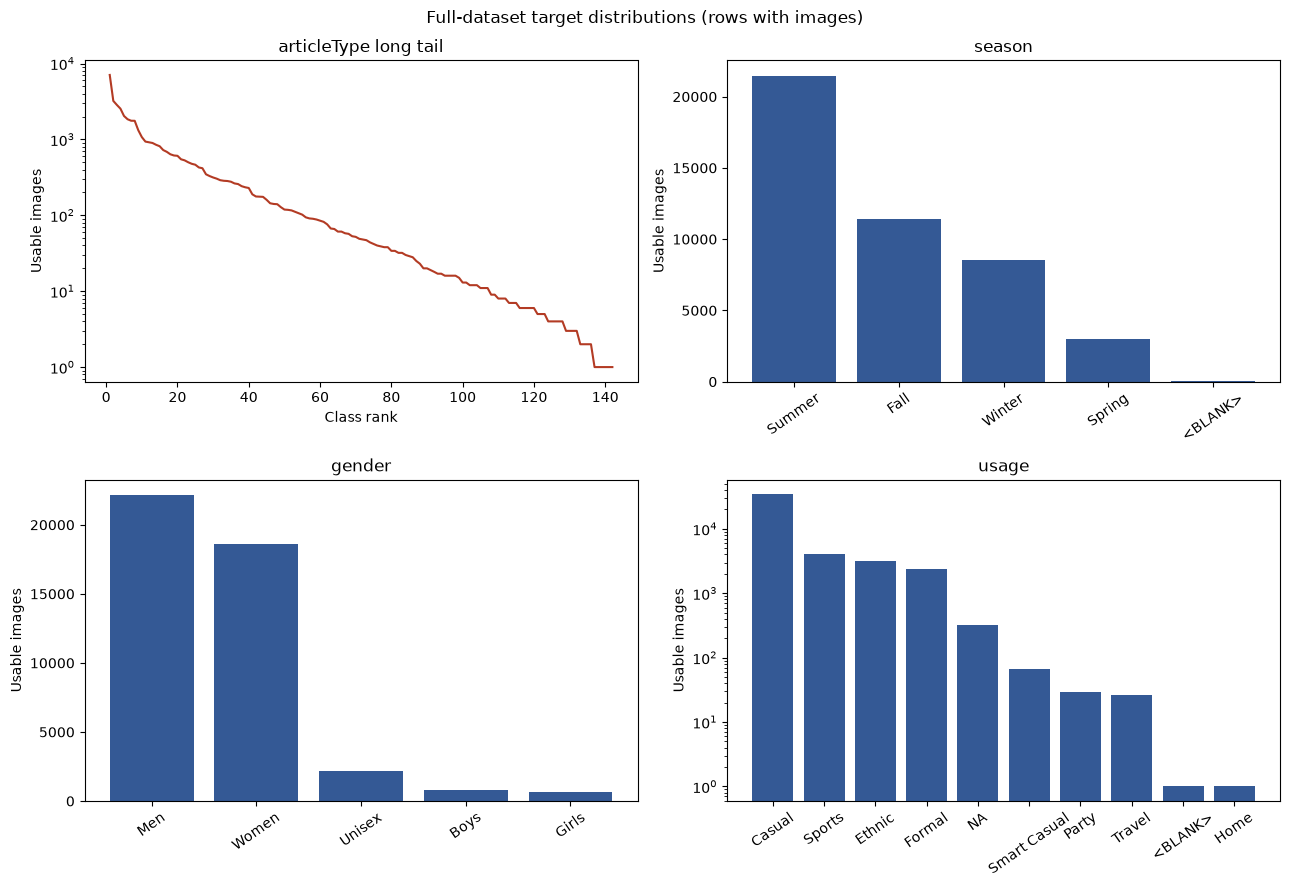

In [4]:
target_summaries = target_summary(usable_styles, TARGET_COLUMNS)
display(target_summaries)

article_distribution = target_distribution(usable_styles, "articleType")
article_distribution["support_band"] = pd.cut(
    article_distribution["count"],
    bins=[0, 1, 2, 4, 9, 19, np.inf],
    labels=["1", "2", "3–4", "5–9", "10–19", "20+"],
)
article_support = (
    article_distribution["support_band"]
    .value_counts(sort=False)
    .rename_axis("images_per_class")
    .reset_index(name="articleType_classes")
)
display(article_support)
display(article_distribution)

figure, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(article_distribution["rank"], article_distribution["count"], color="#b33b24")
axes[0, 0].set_yscale("log")
axes[0, 0].set(title="articleType long tail", xlabel="Class rank", ylabel="Usable images")

for axis, target in zip(
    (axes[0, 1], axes[1, 0], axes[1, 1]),
    ("season", "gender", "usage"),
):
    distribution = target_distribution(usable_styles, target)
    axis.bar(distribution["label"], distribution["count"], color="#345995")
    axis.set(title=target, ylabel="Usable images")
    axis.tick_params(axis="x", rotation=35)
    if target == "usage":
        axis.set_yscale("log")

figure.suptitle("Full-dataset target distributions (rows with images)")
figure.tight_layout()
plt.show()
plt.close(figure)

## 4. High-resolution image sample

A fixed-seed sample of 512 files is fully decoded. This estimates dimensions, colour modes, aspect ratios, and readability without pretending to certify every unsampled file. Run the legacy `audit_images(FULL_IMAGE_DIR)` only when a complete decode-and-hash audit is worth reading the entire 14 GB collection.

Decoded sample: 512 / 512


,width,height,mode,sample_count
0,1080,1440,RGB,300
1,1800,2400,RGB,209
2,360,480,RGB,2
3,150,200,RGB,1


,id,path,width,height,mode,error,bytes,megapixels,aspect_ratio


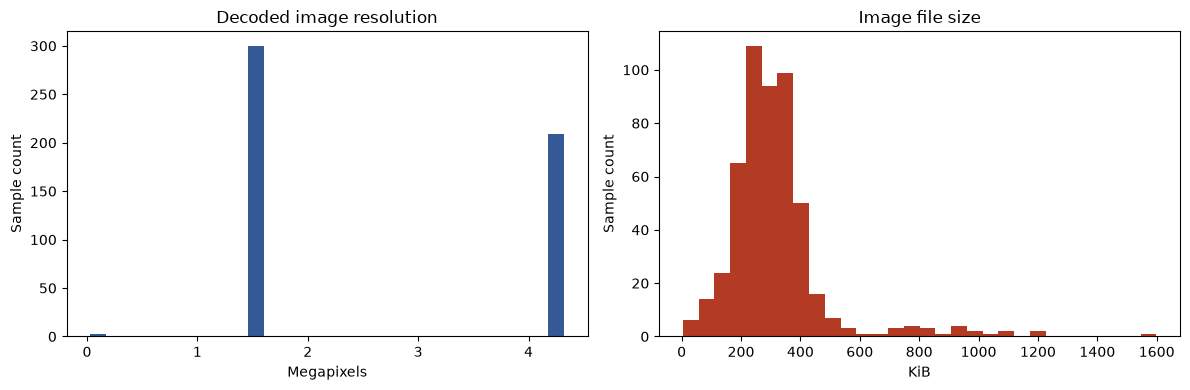

In [5]:
image_sample = audit_image_sample(
    image_inventory,
    sample_size=IMAGE_SAMPLE_SIZE,
    seed=RANDOM_SEED,
)
image_sample = image_sample.merge(
    image_inventory[["id", "bytes"]],
    on="id",
    how="left",
    validate="one_to_one",
)
image_sample["megapixels"] = image_sample["width"] * image_sample["height"] / 1_000_000
image_sample["aspect_ratio"] = image_sample["width"] / image_sample["height"]

sample_errors = image_sample.loc[image_sample["error"].ne("")]
dimension_summary = (
    image_sample.groupby(["width", "height", "mode"], dropna=False)
    .size()
    .reset_index(name="sample_count")
    .sort_values("sample_count", ascending=False, ignore_index=True)
)

print(f"Decoded sample: {len(image_sample) - len(sample_errors):,} / {len(image_sample):,}")
display(dimension_summary.head(20))
display(sample_errors)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(image_sample["megapixels"].dropna(), bins=30, color="#345995")
axes[0].set(title="Decoded image resolution", xlabel="Megapixels", ylabel="Sample count")
axes[1].hist(image_sample["bytes"].dropna() / 1024, bins=30, color="#b33b24")
axes[1].set(title="Image file size", xlabel="KiB", ylabel="Sample count")
figure.tight_layout()
plt.show()
plt.close(figure)

## 5. Stratified visual review

The next grids use seed `2753`. The first samples three images from each of the five most common article types. The second shows up to ten singleton/doubleton classes. Rare classes deserve manual review before modelling because they may represent valid niche products, inconsistent taxonomy, or labels that cannot be evaluated reliably.

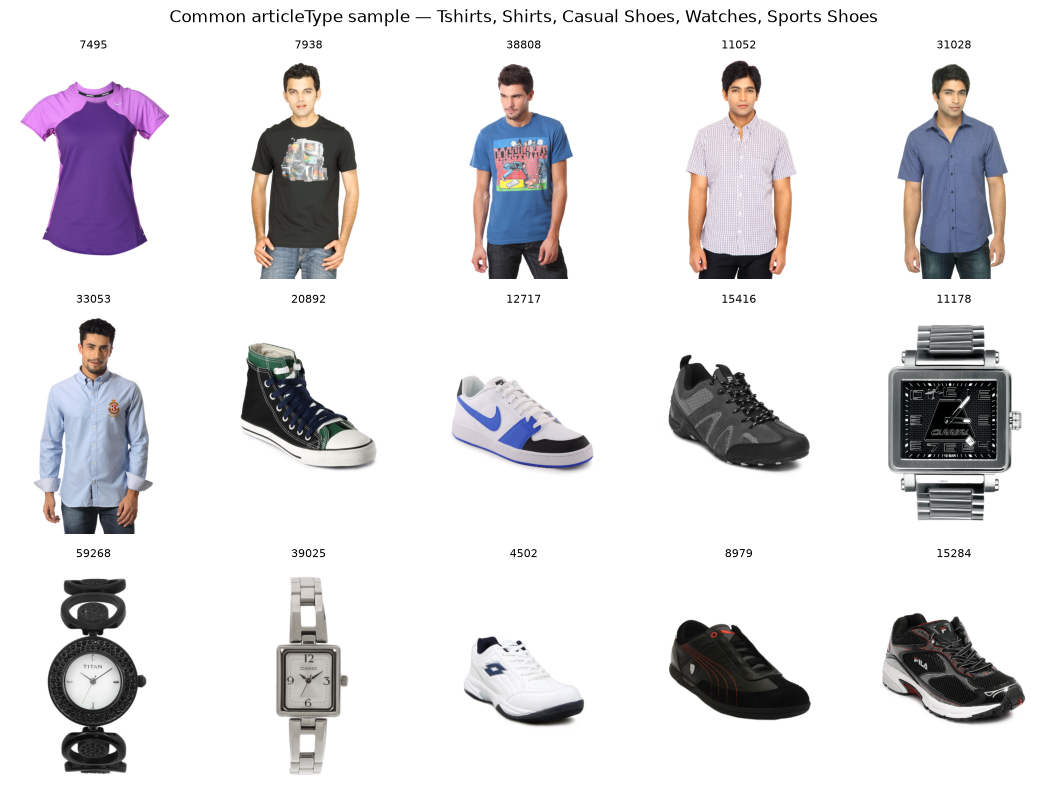

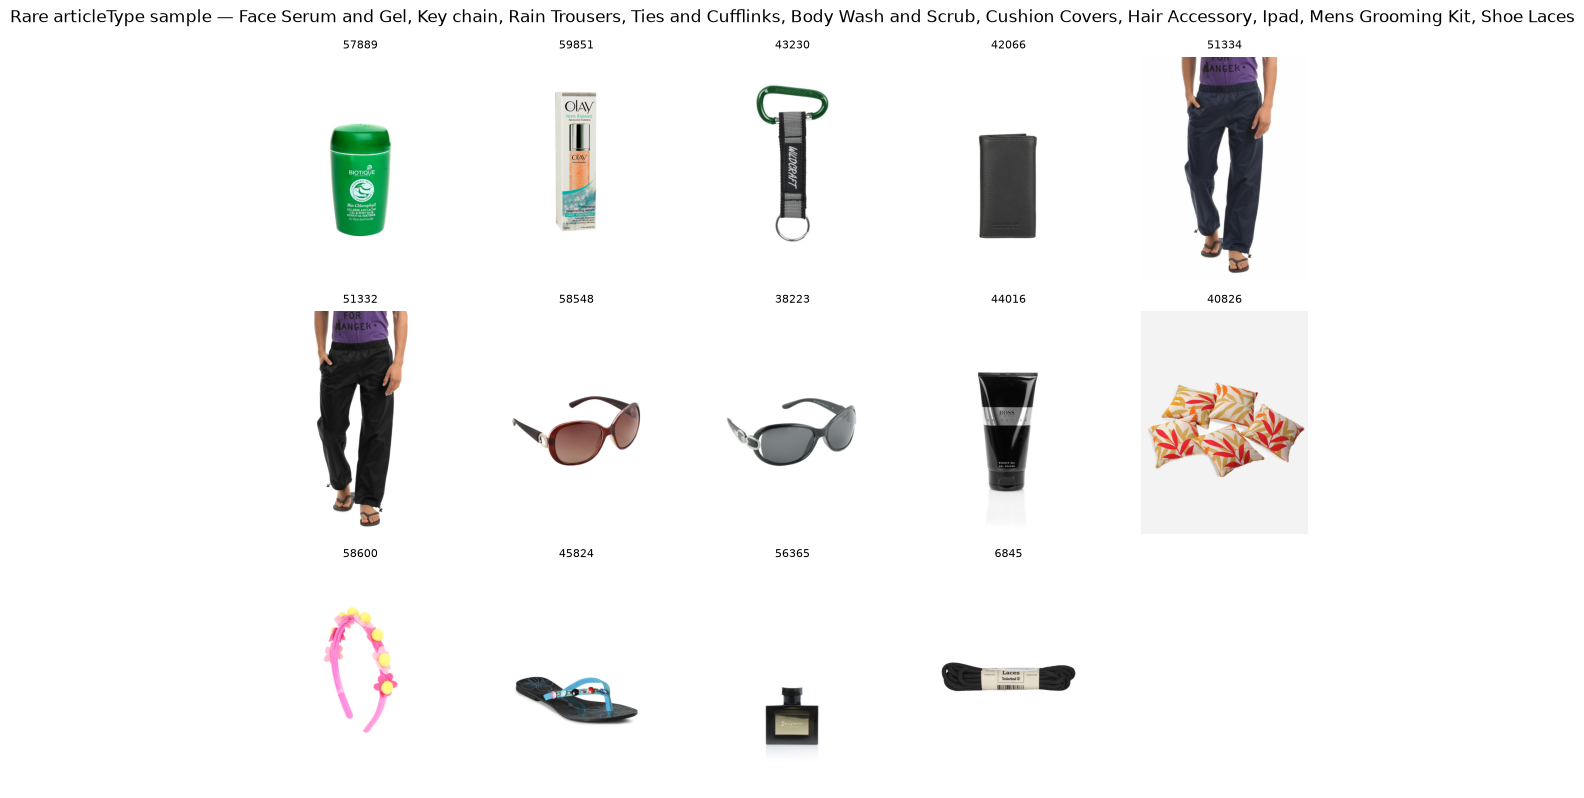

In [6]:
common_labels = article_distribution.head(5)["label"].tolist()
common_ids = sample_ids(
    usable_styles,
    target="articleType",
    labels=common_labels,
    per_label=3,
    seed=RANDOM_SEED,
)
common_figure = plot_image_grid(
    common_ids,
    FULL_IMAGE_DIR,
    title=f"Common articleType sample — {', '.join(common_labels)}",
    columns=5,
)
plt.show()
plt.close(common_figure)

rare_labels = article_distribution.loc[
    article_distribution["count"].le(2), "label"
].head(10).tolist()
rare_ids = sample_ids(
    usable_styles,
    target="articleType",
    labels=rare_labels,
    per_label=2,
    seed=RANDOM_SEED,
)
rare_figure = plot_image_grid(
    rare_ids,
    FULL_IMAGE_DIR,
    title=f"Rare articleType sample — {', '.join(rare_labels)}",
    columns=5,
)
plt.show()
plt.close(rare_figure)

## 6. Modelling readiness and leakage guard

The assignment defines 38,617 labelled training rows and 5,829 held-out test images. This full source has labels for the combined collection. Because `data/test/styles_prediction.csv` is currently absent, the official test membership cannot be reconstructed from this directory alone.

**Do not create a random replacement test split and call it the official evaluation.** First restore the official prediction template (or another authoritative list of its 5,829 IDs), then:

1. quarantine those IDs before fitting encoders, imputers, augmentations, or models;
2. build development splits only from the remaining official training IDs;
3. group confirmed duplicates before splitting;
4. resize images in the data loader rather than materialising another uncontrolled copy; and
5. keep macro-F1 and per-class support visible because `articleType` has a severe long tail.

The complete source may still be used for clearly labelled, non-assignment experiments where no claim is made about the official held-out score.

In [ ]:
OFFICIAL_TRAIN_METADATA_ROWS = 38_617
OFFICIAL_TEST_IMAGE_ROWS = 5_829
OFFICIAL_TEST_TEMPLATE = ROOT / "data/test/styles_prediction.csv"

assert len(styles) == OFFICIAL_TRAIN_METADATA_ROWS + OFFICIAL_TEST_IMAGE_ROWS

readiness = pd.DataFrame(
    [
        {
            "check": "Full-source population",
            "evidence": f"{len(styles):,} rows = {OFFICIAL_TRAIN_METADATA_ROWS:,} official train + {OFFICIAL_TEST_IMAGE_ROWS:,} official test",
            "status": "Leakage risk",
            "required_action": "Recover official test IDs before any assignment training",
        },
        {
            "check": "Official test ID template",
            "evidence": str(OFFICIAL_TEST_TEMPLATE),
            "status": "Available" if OFFICIAL_TEST_TEMPLATE.is_file() else "Missing",
            "required_action": "Use its IDs as an immutable exclusion set",
        },
        {
            "check": "Metadata/image coverage",
            "evidence": f"{len(usable_styles):,} usable rows; {len(missing_image_ids)} metadata-only rows",
            "status": "Measured",
            "required_action": "Exclude metadata-only rows from image models",
        },
        {
            "check": "Image integrity",
            "evidence": f"{len(image_sample):,}-file deterministic sample; {len(sample_errors)} decode failures",
            "status": "Sampled, not exhaustive",
            "required_action": "Retain defensive loader error handling",
        },
        {
            "check": "Class support",
            "evidence": f"{article_distribution['label'].nunique()} usable articleType labels",
            "status": "Long-tailed",
            "required_action": "Resolve rare-label policy before splitting",
        },
    ]
)

readiness

,check,evidence,status,required_action
0,Full-source population,"44,446 rows = 38,617 official train + 5,829 official test",Leakage risk,Recover official test IDs before any assignment training
1,Official test ID template,/localhome/local-lintran/MLA2/data/test/styles_prediction.csv,Available,Use its IDs as an immutable exclusion set
2,Metadata/image coverage,"44,441 usable rows; 5 metadata-only rows",Measured,Exclude metadata-only rows from image models
3,Image integrity,512-file deterministic sample; 0 decode failures,"Sampled, not exhaustive",Retain defensive loader error handling
4,Class support,142 usable articleType labels,Long-tailed,Resolve rare-label policy before splitting


## 7. Summary

Everything below is recomputed from the variables built earlier in this notebook, so the recap cannot drift away from the audits it describes. The editorial version of the same analysis is published in `docs/eda-full-dataset.html`.

**What is settled.** The four artefacts under `data/train/` are internally consistent: the URL index and the per-item JSON directory account for every metadata row, and no image file exists without a row. The parser defect, the missingness pattern, and the class distributions are measured rather than assumed, and the image collection is far larger and sharper than the assignment subset.

**What is not settled.** Pixel properties come from a 512-file sample, the rare-`articleType` policy is undecided, and the hierarchy cannot be used to merge rare classes mechanically because some labels span more than one category. Most importantly, this source carries labels for the official held-out test images, so it is research material until those IDs are quarantined.

In [ ]:
overflow_rows = max(schema_audit.phantom_nonempty_counts.values(), default=0)
blank_cells = sum(schema_audit.blank_counts.values())
top10_share = article_distribution.head(10)["count"].sum() / len(usable_styles)
singletons = int(article_distribution["count"].eq(1).sum())
thin_classes = int(article_distribution["count"].lt(10).sum())
usage_imbalance = target_summaries.set_index("target").loc["usage", "imbalance_ratio"]
baselines = target_summaries["majority_accuracy"]
sampled_modes = sorted(image_sample["mode"].dropna().unique())
test_row_delta = len(styles) - OFFICIAL_TRAIN_METADATA_ROWS

summary = pd.DataFrame(
    [
        ("Population", f"{len(styles):,} rows; {len(image_inventory):,} images; {len(usable_styles):,} usable"),
        ("Cross-artefact", f"URL index and JSON complete; {len(missing_image_ids)} rows lack a JPG"),
        ("Schema defects", f"{overflow_rows} over-wide rows; {blank_cells} blanks; {schema_audit.literal_na_usage_count} literal 'NA'"),
        ("Label spread", f"{len(article_distribution):,} articleType classes; baselines {baselines.min():.1%}-{baselines.max():.1%}"),
        ("Long tail", f"{singletons} singletons; {thin_classes} classes under 10; top 10 hold {top10_share:.1%}"),
        ("Usage skew", f"Casual dominates at {usage_imbalance:,.0f}x the rarest usage label"),
        ("Pixels", f"median {image_sample['megapixels'].median():.2f} MP; modes {sampled_modes}; {image_inventory['bytes'].sum() / 1024**3:.1f} GiB"),
        ("Sampled integrity", f"{len(sample_errors)} decode failures in {len(image_sample):,} files (not exhaustive)"),
        ("Leakage arithmetic", f"{len(styles):,} - {OFFICIAL_TRAIN_METADATA_ROWS:,} = {test_row_delta:,} official test rows"),
    ],
    columns=["topic", "finding"],
)

assert test_row_delta == OFFICIAL_TEST_IMAGE_ROWS
assert summary["finding"].str.len().max() < 100, "keep findings readable without truncation"

summary.style.hide(axis="index")

topic,finding
Population,"44,446 rows; 44,441 images; 44,441 usable"
Cross-artefact,URL index and JSON complete; 5 rows lack a JPG
Schema defects,22 over-wide rows; 23 blanks; 316 literal 'NA'
Label spread,142 articleType classes; baselines 15.9%-77.4%
Long tail,6 singletons; 35 classes under 10; top 10 hold 57.3%
Usage skew,"Casual dominates at 34,409x the rarest usage label"
Pixels,median 1.56 MP; modes ['RGB']; 13.9 GiB
Sampled integrity,0 decode failures in 512 files (not exhaustive)
Leakage arithmetic,"44,446 - 38,617 = 5,829 official test rows"


### Next steps, in order

1. **Restore `data/test/styles_prediction.csv`** (or another authoritative list of the 5,829 official test IDs) and treat it as an immutable exclusion set. Nothing else on this list can be done honestly first.
2. **Rebuild the assignment train/test directories** from this source using those IDs, keeping the official training population intact so `00_eda.ipynb` remains comparable.
3. **Decide the rare-`articleType` policy** — keep, exclude per task, or merge through the hierarchy — and record the evidence for whichever is chosen, noting the 25 labels whose category is ambiguous.
4. **Choose one documented resize target** and apply it in the data loader; do not materialise a second uncontrolled copy of a 13.9 GiB collection.
5. **Re-audit the test partition separately** once it exists, because sampled readability here says nothing about those files.

This notebook writes no split, no cleaned artefact, and no model. Section 6 states the constraints that `01_preprocessing.ipynb` inherits.